<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH06/CH06_NB01_Knowledge_Recovery_T4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

# **Rearchitecting LLMs**
## **Chapter 6: Knowledge Recovery**
### Removing 4 less important Transformer Blocks

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/🤗%20Hugging%20Face-blue)](https://huggingface.co/oopere)

---

**Hardware Environment:** NVIDIA T4 GPU
- **Model:** google/gemma-3-270m (Teacher: 18 Transformer Blocks) → Pruned Student (14 Transformer Blocks)
- **Dataset:** Cosmopedia (2,000 samples, 5 epochs)

---

## Overview

This notebook demonstrates **Knowledge Distillation** for recovering performance in a depth-pruned model. We removed 4 less important Transformer Blocks (layers **8, 9, 14, 16**) from the **google/gemma-3-270m** model, reducing it from **18 to 14 layers**.

### Training Configuration
- **Dataset**: Cosmopedia (200 samples from 4 subsets: stories, wikihow, openstax, web_samples_v1)
- **Training**: 5 epochs, learning rate 2e-5, batch size 2
- **Hardware**: NVIDIA T4 GPU
- **Distillation Method**: Advanced KD with Skew KLD + Feature Dynamics Distillation (FDD)
- **Layer Mapping**: Selected-Layer strategy (maintains original indices)
- **Training Time**: 8.9 minutes

## Setting up notebook

In [1]:
#Samples in the training dataset.
RECOVERY_SAMPLES = 200

EPOCHS=5
LEARNING_RATE=2e-5  #1e-5
BATCH_SIZE = 2

# Flag to skip benchmarks during development (set to True for final run)
RUN_FULL_BENCHMARKS = True
BENCHMARK_LIMIT = 100  #From 100 for quick testing to None for full evaluation
BENCHMARK_TASKS = [
      "arc_easy",
      "winogrande",
      "hellaswag",
      "lambada_openai",
      "piqa"
] # Define benchmark tasks


In [2]:
# Install required packages
!pip install -q transformers accelerate datasets
!pip install -q optipfair  # For creating pruned model on-the-fly
!pip install -q matplotlib seaborn tqdm
!pip install -q lm_eval
!pip install -q langdetect
!pip install -q codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.1/65.1 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 26.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.5/380.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import torch, gc
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer
)
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm.auto import tqdm
from copy import deepcopy
import warnings

warnings.filterwarnings('ignore')

# Check PyTorch version and device
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [4]:
def set_seed(seed=42):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(42)
print("✓ Random seed set to 42")

✓ Random seed set to 42


In [5]:
# Download utils.py from GitHub repository
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

# Verify download
import os
if os.path.exists('utils.py'):
    print("✅ utils.py downloaded successfully")
else:
    print("❌ Failed to download utils.py")

from utils import (
    evaluate_metrics,  # Loss & Perplexity
    clear_gpu_cache
)

✅ utils.py downloaded successfully


## Load Models and Create Pruned Student

In [6]:
MODEL_NAME = "google/gemma-3-270m"

print(f"Loading Teacher model: {MODEL_NAME}")
teacher_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None
)

# Freeze teacher (we never update it)
teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Print architecture info
n_teacher_layers = len(teacher_model.model.layers)
hidden_dim = teacher_model.config.hidden_size

print(f"\n{'='*60}")
print(f"Teacher Model: {MODEL_NAME}")
print(f"{'='*60}")
print(f"Total layers: {n_teacher_layers}")
print(f"Hidden dimension: {hidden_dim}")
print(f"Total parameters: {teacher_model.num_parameters():,}")
print(f"Memory footprint: {teacher_model.get_memory_footprint() / 1e9:.2f} GB")
print(f"{'='*60}\n")

Loading Teacher model: google/gemma-3-270m


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]


Teacher Model: google/gemma-3-270m
Total layers: 18
Hidden dimension: 640
Total parameters: 268,098,176
Memory footprint: 0.54 GB



## 6.1.2 Prepare Training Dataset

In [7]:
from datasets import load_dataset, Dataset
from tqdm.auto import tqdm
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

# Define tokenization parameters
MAX_LENGTH = 512

def tokenize_function(examples):
    """Tokenize text samples for training"""
    texts = examples['text'] if isinstance(examples, dict) else examples
    return tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

print(f"✓ Tokenization function ready (max_length={MAX_LENGTH})")

# Load Cosmopedia dataset
print("\nLoading Cosmopedia dataset...")
dataset_name = "HuggingFaceTB/cosmopedia"
subsets = ["stories", "wikihow", "openstax", "web_samples_v1"]
samples_per_subset = int(RECOVERY_SAMPLES / 4)
num_samples = samples_per_subset * len(subsets)

print(f"Loading {len(subsets)} subsets with {samples_per_subset:,} samples each...")

all_samples = []
for subset in subsets:
    print(f"  Loading {subset}...")
    subset_data = load_dataset(dataset_name, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(samples_per_subset))
    all_samples.extend(subset_samples)
    print(f"    ✓ {len(subset_samples):,} samples from {subset}")

print(f"✓ Total samples loaded: {len(all_samples):,}")

# Convert to HuggingFace Dataset
distillation_dataset = Dataset.from_dict({'text': [s['text'] for s in all_samples]})
print(f"✓ Cosmopedia dataset ready: {len(distillation_dataset):,} samples")

# ==============================================================================
# Tokenization and Train/Val Split
# ==============================================================================

print("\nPreparing DataLoader with Train/Val split...")

# 1. Tokenize all samples
print("  Converting dataset to list...")
dataset_list = list(distillation_dataset)
texts = [item['text'] for item in dataset_list]

print(f"  Tokenizing {len(texts):,} samples...")
tokenized_data = []
batch_size = 1000
for i in tqdm(range(0, len(texts), batch_size), desc="Tokenizing"):
    batch_texts = texts[i:i+batch_size]
    batch_tokens = tokenizer(
        batch_texts,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    tokenized_data.append(batch_tokens)

# Combine all batches
input_ids = torch.cat([batch['input_ids'] for batch in tokenized_data], dim=0)
attention_mask = torch.cat([batch['attention_mask'] for batch in tokenized_data], dim=0)

# 2. Create full dataset
full_dataset = TensorDataset(input_ids, attention_mask)

# 3. Split into Train (90%) and Validation (10%)
# This prevents overfitting metrics - we now evaluate on UNSEEN data
# Using fixed seed for reproducibility across runs
generator = torch.Generator().manual_seed(42)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=generator
)

# 4. Create TWO independent DataLoaders
# Train DataLoader: shuffle=True for better learning
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Validation DataLoader: shuffle=False (not needed for evaluation)
# This is used for computing unbiased PPL metrics
eval_dataloader_raw = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\n✓ DataLoaders ready:")
print(f"  Total samples: {len(full_dataset):,}")
print(f"  - Training samples: {len(train_dataset):,} ({len(train_dataloader):,} batches)")
print(f"  - Validation samples: {len(val_dataset):,} ({len(eval_dataloader_raw):,} batches)")
print(f"  Batch size: {BATCH_SIZE}")
print(f"\n⚠️  IMPORTANT: PPL is now computed on validation set (not training data)")
print(f"  This provides honest generalization metrics")

# ==============================================================================
# Code for Evaluations (wrapper class)
# ==============================================================================

class DictDataLoader:
    """Wrapper to convert TensorDataset tuples to dictionaries"""
    def __init__(self, dataloader):
        self.dataloader = dataloader

    def __iter__(self):
        for input_ids, attention_mask in self.dataloader:
            yield {
                'input_ids': input_ids,
                'attention_mask': attention_mask
            }

    def __len__(self):
        return len(self.dataloader)

eval_dataloader = DictDataLoader(eval_dataloader_raw)


✓ Tokenization function ready (max_length=512)

Loading Cosmopedia dataset...
Loading 4 subsets with 50 samples each...
  Loading stories...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

    ✓ 50 samples from stories
  Loading wikihow...


...

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/139 [00:00<?, ?it/s]

    ✓ 50 samples from web_samples_v1
✓ Total samples loaded: 200
✓ Cosmopedia dataset ready: 200 samples

Preparing DataLoader with Train/Val split...
  Converting dataset to list...
  Tokenizing 200 samples...


Tokenizing:   0%|          | 0/1 [00:00<?, ?it/s]


✓ DataLoaders ready:
  Total samples: 200
  - Training samples: 180 (90 batches)
  - Validation samples: 20 (10 batches)
  Batch size: 2

⚠️  IMPORTANT: PPL is now computed on validation set (not training data)
  This provides honest generalization metrics


### Pruned model

In [8]:
import optipfair as opf

print("Creating Student model with depth pruning...")

# IMPORTANT: Use deepcopy to avoid modifying the original model
student_model = deepcopy(teacher_model)
importance_scores = opf.analyze_layer_importance(student_model, train_dataloader, show_progress=True)

Creating Student model with depth pruning...


Processing batches: 100%|██████████| 90/90 [00:25<00:00,  3.57it/s]


In [9]:
LAYERS_TO_REMOVE = sorted(importance_scores.keys(), key=lambda x: importance_scores[x])[:4]
print (LAYERS_TO_REMOVE)

[9, 8, 14, 16]


In [10]:
student_model = opf.prune_model_depth(
    model=student_model,
    layer_indices=LAYERS_TO_REMOVE,
    show_progress=True,
)

# IMPORTANT: Unfreeze student parameters!
# The deepcopy inherited requires_grad=False from the frozen teacher
for param in student_model.parameters():
    param.requires_grad = True

# Get student info
n_student_layers = len(student_model.model.layers)

print(f"\n{'='*60}")
print(f"Student Model (Depth Pruned)")
print(f"{'='*60}")
print(f"Total layers: {n_student_layers} (removed {LAYERS_TO_REMOVE})")
print(f"Hidden dimension: {hidden_dim} (unchanged)")
print(f"Total parameters: {student_model.num_parameters():,}")
print(f"{'='*60}\n")

print(f"✓ Student has {n_student_layers} layers vs Teacher's {n_teacher_layers} layers")
print(f"✓ This creates the DEPTH MISMATCH problem we'll solve with layer mapping")
print(f"✓ Student parameters unfrozen and ready for training")

Removing layers: 100%|██████████| 18/18 [00:00<00:00, 263057.39it/s]


Student Model (Depth Pruned)
Total layers: 14 (removed [9, 8, 14, 16])
Hidden dimension: 640 (unchanged)
Total parameters: 245,803,648

✓ Student has 14 layers vs Teacher's 18 layers
✓ This creates the DEPTH MISMATCH problem we'll solve with layer mapping
✓ Student parameters unfrozen and ready for training


In [11]:
# Evaluate Teacher (baseline)
print("Evaluating Teacher...")
teacher_metrics = evaluate_metrics(teacher_model, eval_dataloader, device=device)
teacher_loss = teacher_metrics['loss']
teacher_ppl = teacher_metrics['perplexity']

if RUN_FULL_BENCHMARKS:
  from utils import model_evaluation
  benchmark_results = {}
  results = model_evaluation(
      model_obj=teacher_model,
      tokenizer=tokenizer,
      tasks=BENCHMARK_TASKS,
      device=device,
      limit=BENCHMARK_LIMIT,
      batch_size="auto" #4
      )
  benchmark_results['teacher'] = results

Evaluating Teacher...


Evaluating: 100%|██████████| 10/10 [00:02<00:00,  3.71it/s]


Starting lm-eval on model 'google/gemma-3-270m' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (limit=100)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/1838 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3084 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 1299/1299 [01:09<00:00, 18.57it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:00<00:00, 107.96it/s]


In [12]:
# Evaluate Teacher (baseline)
print("Evaluating Pruned Student (no training)...")
student_pruned = deepcopy(student_model)
student_metrics = evaluate_metrics(student_pruned, eval_dataloader, device=device)
student_loss = student_metrics['loss']
student_ppl = student_metrics['perplexity']

if RUN_FULL_BENCHMARKS:
    results = model_evaluation(
    model_obj=student_pruned,
    tokenizer=tokenizer,
    tasks=BENCHMARK_TASKS,
    device=device,
    limit=BENCHMARK_LIMIT,
    batch_size="auto" #4
    )

    benchmark_results['student_pruned'] = results

Evaluating Pruned Student (no training)...


Evaluating: 100%|██████████| 10/10 [00:02<00:00,  3.83it/s]


Starting lm-eval on model 'google/gemma-3-270m' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (limit=100)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 1299/1299 [00:51<00:00, 25.09it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:01<00:00, 75.19it/s]


## 6.2 Implement Layer Mapping Strategies

In [13]:
def create_layer_map_uniform(n_student, n_teacher):
    """
    Uniform layer mapping: Distribute student layers proportionally across teacher layers

    Args:
        n_student: Number of student layers
        n_teacher: Number of teacher layers

    Returns:
        List of teacher layer indices for each student layer
    """
    teacher_indices = []
    for i in range(n_student):
        teacher_idx = int(i * n_teacher / n_student)
        teacher_indices.append(teacher_idx)
    return teacher_indices


def create_layer_map_last(n_student, n_teacher):
    """
    Last-layer alignment: Map student layers to the deepest teacher layers

    Args:
        n_student: Number of student layers
        n_teacher: Number of teacher layers

    Returns:
        List of teacher layer indices for each student layer
    """
    offset = n_teacher - n_student
    return [i + offset for i in range(n_student)]

def create_layer_map_original_indices(student_model, teacher_model, removed_layers):
    """
    Correct mapping for sparse layers based on original indices
    """
    n_teacher = len(teacher_model.model.layers)

    # Reconstruct the original student indices
    original_indices = []
    teacher_idx = 0
    for i in range(n_teacher):
        if i not in removed_layers:
            original_indices.append(i)

    # The mapping is direct: each student layer maps to its original index
    layer_map = original_indices

    print(f"Original Teacher layers: {list(range(n_teacher))}")
    print(f"Removed layers: {sorted(removed_layers)}")
    print(f"Student original indices: {original_indices}")
    print(f"Mapping: {layer_map}")

    return layer_map

# Test both strategies
print("Testing layer mapping strategies:")
print(f"Student layers: {n_student_layers}")
print(f"Teacher layers: {n_teacher_layers}")

uniform_map = create_layer_map_uniform(n_student_layers, n_teacher_layers)
last_map = create_layer_map_last(n_student_layers, n_teacher_layers)
layer_map = create_layer_map_original_indices(
    student_model,
    teacher_model,
    LAYERS_TO_REMOVE
)

print(f"\n✓ Uniform mapping: {uniform_map[:5]}... (showing first 5)")
print(f"✓ Last-layer mapping: {last_map[:5]}... (showing first 5)")

Testing layer mapping strategies:
Student layers: 14
Teacher layers: 18
Original Teacher layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Removed layers: [8, 9, 14, 16]
Student original indices: [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 15, 17]
Mapping: [0, 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 13, 15, 17]

✓ Uniform mapping: [0, 1, 2, 3, 5]... (showing first 5)
✓ Last-layer mapping: [4, 5, 6, 7, 8]... (showing first 5)


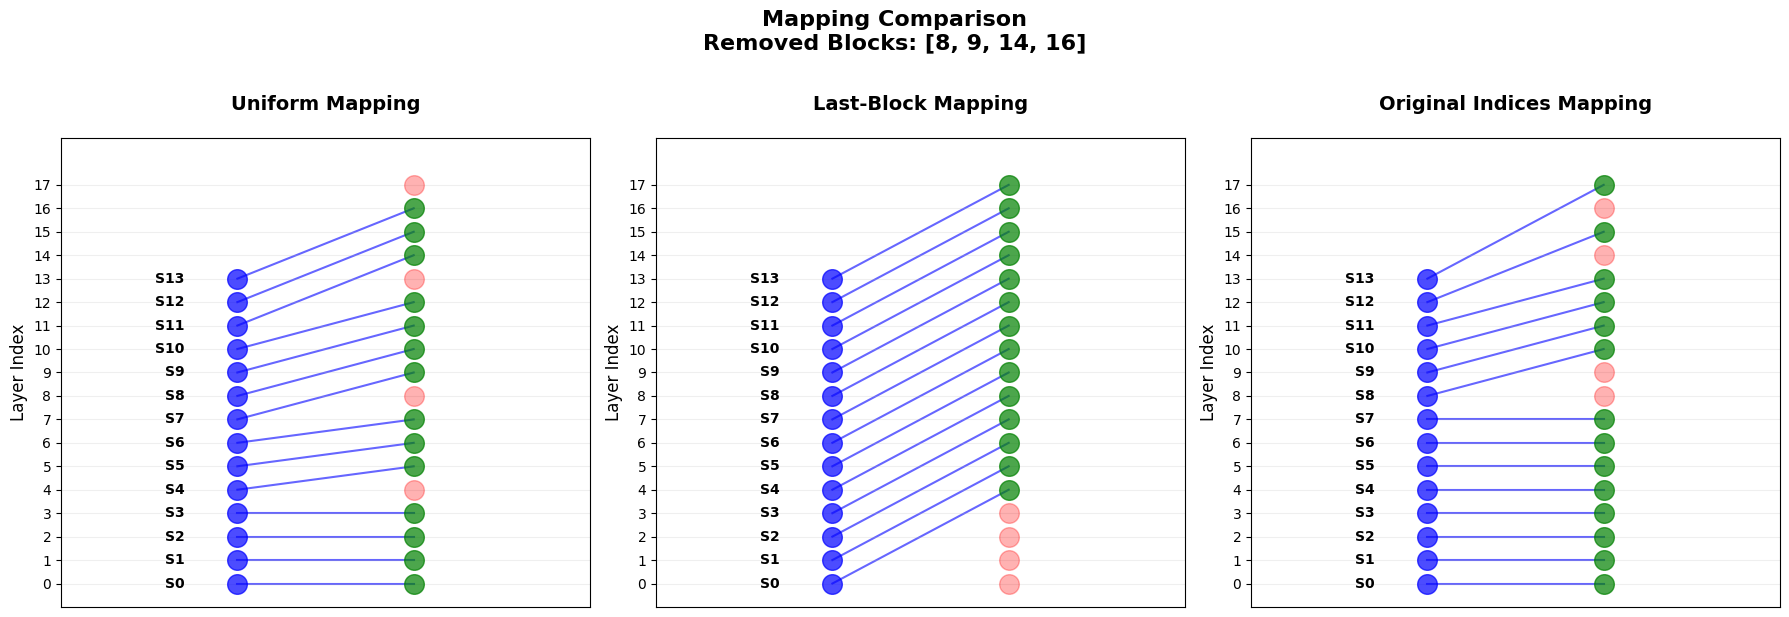

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_layer_mappings_comparison(
    n_student,
    n_teacher,
    removed_layers,
    uniform_map,
    last_map,
    original_map
):

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    mappings = [
        ("Uniform Mapping", uniform_map),
        ("Last-Block Mapping", last_map),
        ("Original Indices Mapping", original_map)
    ]

    for idx, (title, mapping) in enumerate(mappings):
        ax = axes[idx]

        # Config limits
        ax.set_xlim(-1, 2)
        ax.set_ylim(-1, max(n_teacher, n_student) + 1)

        # Draw student layers(left)
        student_x = 0
        for i in range(n_student):
            ax.scatter(student_x, i, s=200, c='blue', zorder=3, alpha=0.7)
            ax.text(student_x - 0.3, i, f'S{i}', fontsize=10,
                   ha='right', va='center', fontweight='bold')

        # Draw teacher layers (right)
        teacher_x = 1
        mapped_teachers = set(mapping)

        for i in range(n_teacher):
            color = 'green' if i in mapped_teachers else 'red'  # ✅ DINÁMICO
            alpha = 0.7 if i in mapped_teachers else 0.3
            ax.scatter(teacher_x, i, s=200, c=color, zorder=3, alpha=alpha)

        # Draw connections
        for student_idx, teacher_idx in enumerate(mapping):
          # All connections are valid - blue line always
          ax.plot([student_x, teacher_x],
                [student_idx, teacher_idx],
                '-',  # solid line
                color='blue',
                linewidth=1.5,
                alpha=0.6,
                zorder=1)


        # Labels & Tittle
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
        ax.set_yticks(range(max(n_teacher, n_student)))
        ax.set_xticks([])
        ax.set_ylabel('Layer Index', fontsize=12)
        ax.grid(True, alpha=0.2, axis='y')

        # Legend
        from matplotlib.patches import Patch
        #legend_elements = [
        #    Patch(facecolor='blue', alpha=0.7, label='Student Layers'),
        #    Patch(facecolor='green', alpha=0.7, label='Teacher (has student match)'),
        #    Patch(facecolor='red', alpha=0.3, label='Teacher (no student match)')  # ✅ CLARO
        #]
        #ax.legend(handles=legend_elements, loc='upper center',
        #         bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=9)

    plt.suptitle(f'Mapping Comparison\nRemoved Blocks: {sorted(removed_layers)}',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# ===== use visualization =====
visualize_layer_mappings_comparison(
    n_student=n_student_layers,
    n_teacher=n_teacher_layers,
    removed_layers=LAYERS_TO_REMOVE,
    uniform_map=uniform_map,
    last_map=last_map,
    original_map=layer_map
)

## 6.3.1 Implement Compound Loss + 6.4

This function is created with the code from Listing 6.6 section 6.3.1 in the book plus the additions from section 6.4 Advanced Recovery (Skew KLD / Feature Dynamics Distillation).

In [15]:
def compute_compound_loss_advanced(
    student_logits,
    teacher_logits,
    student_hiddens,
    teacher_hiddens,
    labels,
    layer_map,
    alpha=0.1,
    beta=0.8,
    gamma=0.1,
    delta=0.1,
    temperature=2.0,
    skew_alpha=0.1
):
    """
    Advanced compound loss combining Skew Forward KL Divergence (SFKL) and FDD.
    All components operate only on valid (non-padding) tokens,
    identified by labels != -100.

    SFKL (Ko et al., 2024 - DistiLLM): KL(teacher || mixed), where
    mixed = skew_alpha * student + (1 - skew_alpha) * teacher.
    Mixing student into the target distribution keeps the KL bounded and
    well-behaved when teacher and student are far apart (e.g., right after
    structural pruning). Gradient flows through student via `mixed`.
    """
    device = student_logits.device

    # 1. TASK LOSS (Cross-Entropy with hard labels)
    shift_logits = student_logits[..., :-1, :].contiguous()
    shift_labels = labels[..., 1:].contiguous()

    loss_task = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1),
        ignore_index=-100
    )

    # Shared valid-token mask
    valid_mask = (shift_labels != -100)            # [batch, seq_len - 1]
    num_valid = valid_mask.sum().clamp(min=1)

    # 2. SKEW FORWARD KL — KL(teacher || mixed), masked
    # Teacher detached; student probs keep gradient through `mixed`.
    teacher_probs = F.softmax(
        teacher_logits[..., :-1, :] / temperature, dim=-1
    ).detach()
    student_probs = F.softmax(
        student_logits[..., :-1, :] / temperature, dim=-1
    )  # NO detach: this is where the gradient enters

    mixed_probs = skew_alpha * student_probs + (1.0 - skew_alpha) * teacher_probs

    eps = 1e-9
    log_teacher = torch.log(teacher_probs + eps)
    log_mixed = torch.log(mixed_probs + eps)

    # KL(teacher || mixed) per token, then mask + normalize
    kl_per_token = (teacher_probs * (log_teacher - log_mixed)).sum(dim=-1)
    loss_logits = (kl_per_token * valid_mask).sum() / num_valid
    loss_logits = loss_logits * (temperature ** 2)

    # 3. TRAJECTORY LOSS (Cosine Similarity of Hidden States) — masked
    if gamma > 0 and student_hiddens is not None and teacher_hiddens is not None:
        loss_trajectory = 0.0
        flat_mask = valid_mask.reshape(-1)

        for student_idx, teacher_idx in enumerate(layer_map):
            student_h = student_hiddens[student_idx][:, :-1, :].contiguous()
            teacher_h = teacher_hiddens[teacher_idx][:, :-1, :].contiguous()

            student_flat = student_h.reshape(-1, student_h.size(-1))
            teacher_flat = teacher_h.reshape(-1, teacher_h.size(-1))

            student_norm = F.normalize(student_flat, p=2, dim=1)
            teacher_norm = F.normalize(teacher_flat, p=2, dim=1)

            cos_sim_per_token = (student_norm * teacher_norm).sum(dim=1)
            cos_sim = (cos_sim_per_token * flat_mask).sum() / num_valid
            loss_trajectory += (1 - cos_sim)

        loss_trajectory = loss_trajectory / len(layer_map)
    else:
        loss_trajectory = torch.tensor(0.0, device=device)

    # 4. FDD DERIVATIVE LOSS — masked
    loss_derivative = torch.tensor(0.0, device=device)
    if delta > 0 and student_hiddens is not None and teacher_hiddens is not None:
        num_derivatives = 0
        flat_mask = valid_mask.reshape(-1)

        for student_idx in range(len(layer_map) - 1):
            teacher_idx = layer_map[student_idx]
            teacher_idx_next = layer_map[student_idx + 1]

            student_delta = (student_hiddens[student_idx + 1][:, :-1, :]
                             - student_hiddens[student_idx][:, :-1, :])
            teacher_delta = (teacher_hiddens[teacher_idx_next][:, :-1, :]
                             - teacher_hiddens[teacher_idx][:, :-1, :])

            student_delta_flat = student_delta.reshape(-1, student_delta.size(-1))
            teacher_delta_flat = teacher_delta.reshape(-1, teacher_delta.size(-1))

            student_delta_norm = F.normalize(student_delta_flat, p=2, dim=1)
            teacher_delta_norm = F.normalize(teacher_delta_flat, p=2, dim=1)

            cos_sim_deriv_per_token = (student_delta_norm * teacher_delta_norm).sum(dim=1)
            cos_sim_deriv = (cos_sim_deriv_per_token * flat_mask).sum() / num_valid
            loss_derivative += (1 - cos_sim_deriv)
            num_derivatives += 1

        if num_derivatives > 0:
            loss_derivative = loss_derivative / num_derivatives

    # COMBINE ALL LOSSES
    total_loss = (
        alpha * loss_task +
        beta * loss_logits +
        gamma * loss_trajectory +
        delta * loss_derivative
    )

    loss_dict = {
        'total': total_loss.item(),
        'task': loss_task.item(),
        'logits': loss_logits.item(),
        'trajectory': loss_trajectory.item(),
        'derivative': loss_derivative.item()
    }

    return total_loss, loss_dict

## 6.3.2 Training Loop Implementation
The code for the train_student_advanced function is the same as the one that can be found in listing 6.7 of the book, with the necessary modifications to call the compute_compound_loss_advanced function.

In [16]:
def train_student_advanced(
    student_model,
    teacher_model,
    dataloader,
    layer_map,
    # Loss weights
    alpha=0.1,           # Task loss
    beta=0.8,            # Skew KLD (logits)
    gamma=0.05,          # Trajectory loss (hidden states)
    delta=0.05,          # FDD derivative loss
    temperature=2.0,
    skew_alpha=0.5,      # Skew interpolation factor
    # Training params
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    experiment_name="experiment",
    accumulation_steps=4
):
    """
    Train student model with Advanced Compound Loss (Skew KLD + FDD).
    """
    optimizer = torch.optim.AdamW(student_model.parameters(), lr=learning_rate)

    student_model.train()
    teacher_model.eval()

    # Decide if we need hidden states (required if using trajectory OR derivative loss)
    request_hidden_states = (gamma > 0 or delta > 0)

    loss_history = {
        'total': [], 'task': [], 'logits': [],
        'trajectory': [], 'derivative': []
    }
    epoch_times = []

    print(f"\n{'='*60}")
    print(f"Starting Training: {experiment_name}")
    print(f"{'='*60}")
    print(f"Epochs: {epochs}")
    print(f"Learning rate: {learning_rate}")
    print(f"Loss weights: α={alpha}, β={beta}, γ={gamma}, δ={delta}")
    print(f"Temperature: {temperature}, Skew α: {skew_alpha}")
    print(f"Hidden states computation: {'ENABLED' if request_hidden_states else 'DISABLED'}")
    print(f"Gradient Accumulation Steps: {accumulation_steps}")
    print(f"Effective Batch Size: {dataloader.batch_size * accumulation_steps}")
    print(f"{'='*60}\n")

    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()

        epoch_losses = {k: [] for k in loss_history.keys()}
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        accumulated_losses = {k: 0.0 for k in loss_history.keys()}
        accumulation_counter = 0

        for batch_idx, (input_ids, attention_mask) in enumerate(progress_bar):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            # Student forward pass
            student_outputs = student_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=request_hidden_states
            )

            # Teacher forward pass (no gradients)
            with torch.no_grad():
                teacher_outputs = teacher_model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    output_hidden_states=request_hidden_states
                )

            # Prepare hidden states (None if not needed)
            student_hiddens = (student_outputs.hidden_states[1:]
                             if request_hidden_states else None)
            teacher_hiddens = (teacher_outputs.hidden_states[1:]
                             if request_hidden_states else None)

            # Compute advanced compound loss
            loss, loss_dict = compute_compound_loss_advanced(
                student_logits=student_outputs.logits,
                teacher_logits=teacher_outputs.logits,
                student_hiddens=student_hiddens,
                teacher_hiddens=teacher_hiddens,
                labels=labels,
                layer_map=layer_map,
                alpha=alpha,
                beta=beta,
                gamma=gamma,
                delta=delta,
                temperature=temperature,
                skew_alpha=skew_alpha
            )

            # Gradient accumulation
            scaled_loss = loss / accumulation_steps
            scaled_loss.backward()

            for key in accumulated_losses:
                accumulated_losses[key] += loss_dict[key]
            accumulation_counter += 1

            # Optimizer step
            if (batch_idx + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

                avg_losses = {k: v / accumulation_counter for k, v in accumulated_losses.items()}
                for key in avg_losses:
                    epoch_losses[key].append(avg_losses[key])

                progress_bar.set_postfix({
                    'loss': f"{avg_losses['total']:.4f}",
                    'task': f"{avg_losses['task']:.4f}",
                    'logits': f"{avg_losses['logits']:.4f}",
                    'traj': f"{avg_losses['trajectory']:.4f}",
                    'deriv': f"{avg_losses['derivative']:.4f}"
                })

                accumulated_losses = {k: 0.0 for k in loss_history.keys()}
                accumulation_counter = 0

        # Handle remaining batches
        if accumulation_counter > 0:
            torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

            avg_losses = {k: v / accumulation_counter for k, v in accumulated_losses.items()}
            for key in avg_losses:
                epoch_losses[key].append(avg_losses[key])

        # Record epoch averages
        for key in epoch_losses:
            if epoch_losses[key]:
                loss_history[key].append(np.mean(epoch_losses[key]))

        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1} avg losses - "
              f"Total: {loss_history['total'][-1]:.4f}, "
              f"Task: {loss_history['task'][-1]:.4f}, "
              f"Logits: {loss_history['logits'][-1]:.4f}, "
              f"Traj: {loss_history['trajectory'][-1]:.4f}, "
              f"Deriv: {loss_history['derivative'][-1]:.4f} "
              f"[{epoch_time:.1f}s]")

    total_time = time.time() - total_start_time
    loss_history['epoch_times_seconds'] = epoch_times
    loss_history['total_time_seconds'] = total_time

    print(f"\n✓ Training completed: {experiment_name}")
    print(f"  Total time: {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"  Avg time per epoch: {np.mean(epoch_times):.1f}s")

    return student_model, loss_history

Advanced KD (Skew KLD + FDD)


In [17]:
# Train with Advanced KD
import time

student_sel_advanced_trained, history_sel_advanced = train_student_advanced(
    student_model=student_model,
    teacher_model=teacher_model,
    dataloader=train_dataloader,
    layer_map=layer_map,
    alpha=0.2,           # Task loss weight
    beta=0.5,            # Skew KLD weight
    gamma=0.1,           # Trajectory (hidden) weight
    delta=0.2,           # FDD derivative weight
    temperature=2.0,
    skew_alpha=0.5,      # Slight mode-seeking bias
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    experiment_name="Selected Layers Advanced KD (Skew KLD + FDD)"
)


Starting Training: Selected Layers Advanced KD (Skew KLD + FDD)
Epochs: 5
Learning rate: 2e-05
Loss weights: α=0.2, β=0.5, γ=0.1, δ=0.2
Temperature: 2.0, Skew α: 0.5
Hidden states computation: ENABLED
Gradient Accumulation Steps: 4
Effective Batch Size: 8



Epoch 1/5:   0%|          | 0/90 [00:00<?, ?it/s]

Epoch 1 avg losses - Total: 1.0633, Task: 3.8668, Logits: 0.5506, Traj: 0.0258, Deriv: 0.0652 [106.7s]


Epoch 2/5:   0%|          | 0/90 [00:00<?, ?it/s]

Epoch 2 avg losses - Total: 0.8815, Task: 3.3349, Logits: 0.3991, Traj: 0.0217, Deriv: 0.0579 [106.7s]


...

Epoch 3 avg losses - Total: 0.8163, Task: 3.1238, Logits: 0.3566, Traj: 0.0203, Deriv: 0.0542 [104.1s]


Epoch 4/5:   0%|          | 0/90 [00:00<?, ?it/s]

Epoch 4 avg losses - Total: 0.7750, Task: 2.9740, Logits: 0.3345, Traj: 0.0198, Deriv: 0.0526 [104.3s]


Epoch 5/5:   0%|          | 0/90 [00:00<?, ?it/s]

Epoch 5 avg losses - Total: 0.7426, Task: 2.8541, Logits: 0.3187, Traj: 0.0193, Deriv: 0.0514 [104.4s]

✓ Training completed: Selected Layers Advanced KD (Skew KLD + FDD)
  Total time: 526.3s (8.8 min)
  Avg time per epoch: 105.3s


In [18]:
# Evaluate Advanced KD
print("Evaluating Advanced KD (Skew KLD + FDD)...")
advanced_sel_metrics = evaluate_metrics(student_sel_advanced_trained, eval_dataloader, device=device)
advanced_sel_loss = advanced_sel_metrics['loss']
advanced_sel_ppl = advanced_sel_metrics['perplexity']

if RUN_FULL_BENCHMARKS:
  results = model_evaluation(
      model_obj=student_sel_advanced_trained,
      tokenizer=tokenizer,
      tasks=BENCHMARK_TASKS,
      device=device,
      limit=BENCHMARK_LIMIT,
      batch_size=16 #4
  )

  benchmark_results['selected_advanced_kd'] = results

Evaluating Advanced KD (Skew KLD + FDD)...


Evaluating: 100%|██████████| 10/10 [00:02<00:00,  3.78it/s]


Starting lm-eval on model 'google/gemma-3-270m' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (limit=100)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 1299/1299 [00:52<00:00, 24.88it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:01<00:00, 61.32it/s]


In [19]:
del student_sel_advanced_trained
clear_gpu_cache()

## Evaluation and Comparison
The data in this notebook isn't reliable since it's been obtained using very few sample records, both for perplexity and for capabilities. To analyze the data it's better to go to the notebooks of the chapter experiments.

In [20]:
# Calculate recovery rates
def recovery_rate(teacher_ppl, pruned_ppl, recovered_ppl):
    """Calculate recovery rate as percentage"""
    degradation = pruned_ppl - teacher_ppl
    recovery = pruned_ppl - recovered_ppl
    return (recovery / degradation) * 100 if degradation > 0 else 0


In [21]:

advanced_sel_recovery = recovery_rate(teacher_ppl, student_ppl, advanced_sel_ppl)


# Print results table
print("\n" + "="*80)
print("EVALUATION RESULTS")
print("="*80)
print(f"{'Model':<40} {'Loss':>10} {'Perplexity':>12} {'Recovery':>12}")
print("-"*80)
print(f"{'Teacher (Original)':<40} {teacher_loss:>10.4f} {teacher_ppl:>12.2f} {'100.0%':>12}")
print(f"{'Student (Pruned, no training)':<40} {student_loss:>10.4f} {student_ppl:>12.2f} {'0.0%':>12}")
print("-"*80)
print(f"{'Selected  (Skew KLD + FDD)':<40} {advanced_sel_loss:>10.4f} {advanced_sel_ppl:>12.2f} {f'{advanced_sel_recovery:.1f}%':>12}")
print("="*80)


EVALUATION RESULTS
Model                                          Loss   Perplexity     Recovery
--------------------------------------------------------------------------------
Teacher (Original)                           2.6139        13.65       100.0%
Student (Pruned, no training)                4.9115       135.85         0.0%
--------------------------------------------------------------------------------
Selected  (Skew KLD + FDD)                   3.2439        25.63        90.2%


In [22]:
# Benchmark Evaluation
if RUN_FULL_BENCHMARKS:

    # Display comparison table
    print("\n" + "="*90)
    print("BENCHMARK COMPARISON TABLE")
    print("="*90)

    # Header
    header = f"{'Model':<25}"
    for task in BENCHMARK_TASKS:
        header += f"{task:<14}"

    print(header)
    print("-"*90)

    # Rows
    for model_name, results in benchmark_results.items():
        row = f"{model_name:<25}"
        for task in BENCHMARK_TASKS:
            if task in results and "error" not in results:
                # Get accuracy or acc_norm depending on task
                metrics = results[task]
                if "acc_norm" in metrics:
                    val = float(metrics["acc_norm"])
                elif "accuracy" in metrics:
                    val = float(metrics["accuracy"])
                else:
                    val = 0.0
                row += f"{val:.4f}        "
            else:
                row += f"{'N/A':<14}"
        print(row)

    print("="*90)

else:
    print("⚠️ Benchmark evaluation skipped (RUN_FULL_BENCHMARKS = False)")
    benchmark_results = {}


BENCHMARK COMPARISON TABLE
Model                    arc_easy      winogrande    hellaswag     lambada_openaipiqa          
------------------------------------------------------------------------------------------
teacher                  0.5900        0.5600        0.5200        0.4300        0.7000        
student_pruned           0.4300        0.5700        0.4700        0.1700        0.5900        
selected_advanced_kd     0.4900        0.6300        0.4600        0.2000        0.6100        


## Visualization

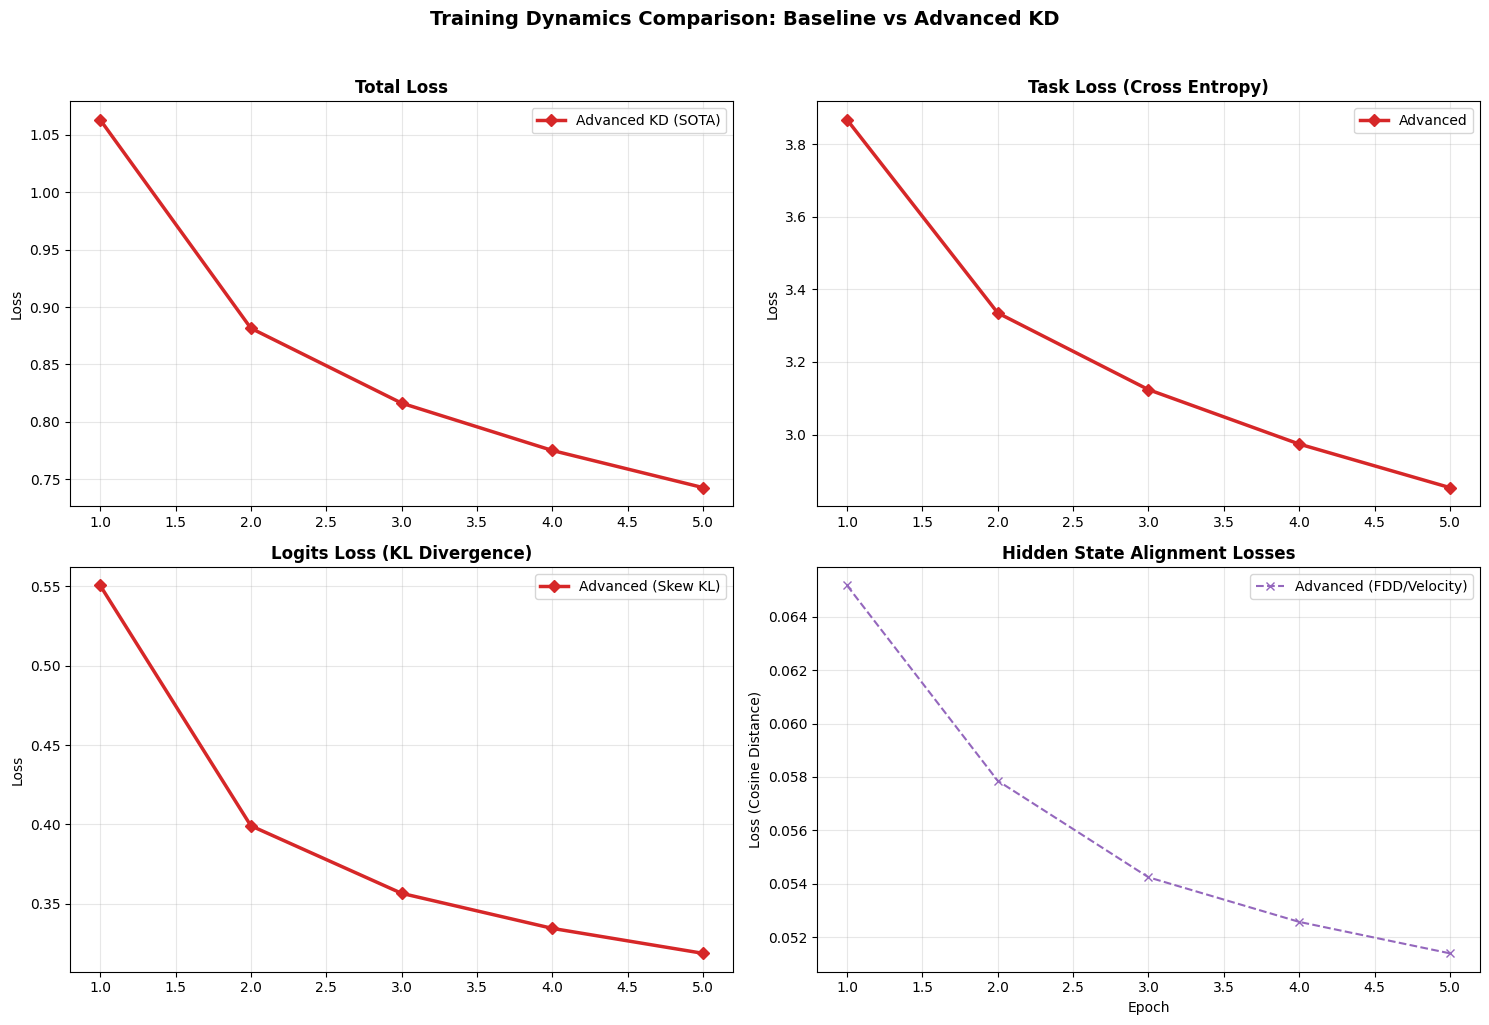

✓ Loss comparison plots generated successfully


In [23]:
import matplotlib.pyplot as plt

colors = {'uniform': '#1f77b4', 'last': '#ff7f0e', 'features': '#2ca02c', 'advanced': '#d62728', 'deriv': '#9467bd'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Use the Selected Advanced KD history (or change to history_uni_advanced if you prefer)
epochs_x = list(range(1, len(history_sel_advanced['total']) + 1))

# --- PLOT 1: Total Loss ---
axes[0, 0].plot(epochs_x, history_sel_advanced['total'], 'D-', label='Advanced KD (SOTA)', color=colors['advanced'], linewidth=2.5)

axes[0, 0].set_title('Total Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# --- PLOT 2: Task Loss ---
axes[0, 1].plot(epochs_x, history_sel_advanced['task'], 'D-', label='Advanced', color=colors['advanced'], linewidth=2.5)

axes[0, 1].set_title('Task Loss (Cross Entropy)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# --- PLOT 3: Logits Loss ---
axes[1, 0].plot(epochs_x, history_sel_advanced['logits'], 'D-', label='Advanced (Skew KL)', color=colors['advanced'], linewidth=2.5)

axes[1, 0].set_title('Logits Loss (KL Divergence)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- PLOT 4: Hidden/Structural Losses ---
axes[1, 1].plot(epochs_x, history_sel_advanced['derivative'], 'x--', label='Advanced (FDD/Velocity)', color=colors['deriv'])

axes[1, 1].set_title('Hidden State Alignment Losses', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Loss (Cosine Distance)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training Dynamics Comparison: Baseline vs Advanced KD',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Loss comparison plots generated successfully")

In [24]:
print("="*120)
print("COMPLETE EVALUATION RESULTS (With Training Time)")
print("="*120)

training_times = {
    "teacher": 0.0,
    "student_pruned": 0.0,
    "selected_advanced_kd": history_sel_advanced['total_time_seconds']      # ✅ Changed
}

all_metrics = {
    "teacher": {
        "time_min": training_times["teacher"] / 60,
        "perplexity": teacher_ppl,
        "recovery_%": 100.0
    },
    "student_pruned": {
        "time_min": training_times["student_pruned"] / 60,
        "perplexity": student_ppl,
        "recovery_%": 0.0
    },
    "selected_advanced_kd": {
        "time_min": training_times["selected_advanced_kd"] / 60,             #
        "perplexity": advanced_sel_ppl,
        "recovery_%": advanced_sel_recovery
    }
}

if 'benchmark_results' in locals() and benchmark_results:
    for model_name in all_metrics.keys():
        if model_name in benchmark_results and "error" not in benchmark_results[model_name]:
            for task_name, task_metrics in benchmark_results[model_name].items():
                if "acc_norm" in task_metrics:
                    all_metrics[model_name][task_name] = float(task_metrics["acc_norm"])
                elif "accuracy" in task_metrics:
                    all_metrics[model_name][task_name] = float(task_metrics["accuracy"])

metric_names = ["time_min", "perplexity", "recovery_%"]
if 'benchmark_results' in locals() and benchmark_results:
    metric_names.extend(BENCHMARK_TASKS)

header = f"{'Model':<25}"
labels = {"time_min": "Time(m)", "perplexity": "PPL", "recovery_%": "Recov%"}

for metric in metric_names:
    label = labels.get(metric, metric)
    header += f"{label:<10}"
print(header)
print("-" * 120)

for model_name, metrics in all_metrics.items():
    row = f"{model_name:<25}"
    for metric in metric_names:
        if metric in metrics:
            val = metrics[metric]
            if metric == "time_min":
                row += f"{val:<10.1f}" if val > 0 else f"{'N/A':<10}"
            elif metric == "perplexity":
                row += f"{val:<10.2f}"
            elif metric == "recovery_%":
                row += f"{val:<10.1f}"
            else: # For benchmark tasks
                row += f"{val*100:<10.1f}"
        else:
            row += f"{'N/A':<10}"
    print(row)
print("="*120)

COMPLETE EVALUATION RESULTS (With Training Time)
Model                    Time(m)   PPL       Recov%    arc_easy  winograndehellaswag lambada_openaipiqa      
------------------------------------------------------------------------------------------------------------------------
teacher                  N/A       13.65     100.0     59.0      56.0      52.0      43.0      70.0      
student_pruned           N/A       135.85    0.0       43.0      57.0      47.0      17.0      59.0      
selected_advanced_kd     8.8       25.63     90.2      49.0      63.0      46.0      20.0      61.0      


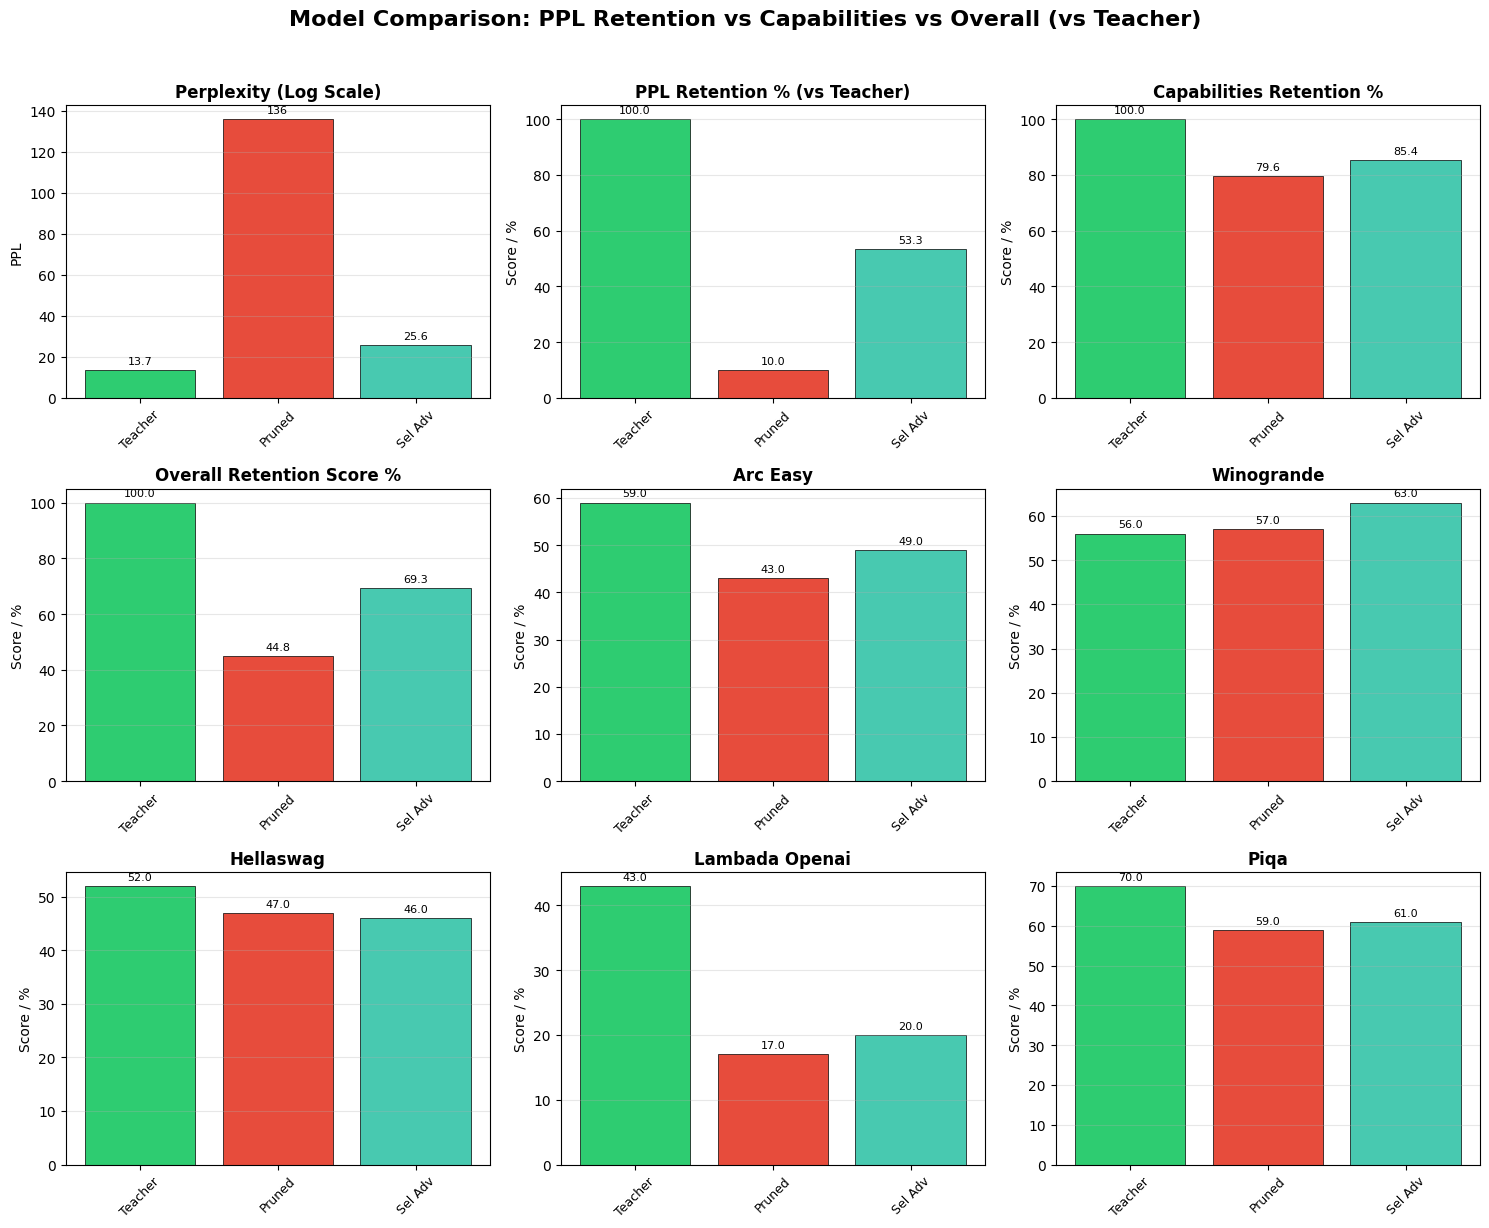

✓ Charts Updated: Now showing PPL Retention % and Overall Retention Score % (vs Teacher)


In [25]:
# ==============================================================================
# Bar Charts: PPL Retention & Overall Retention (vs Teacher)
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP: Models, Names and Colors
model_display_names = {
    "teacher": "Teacher",
    "student_pruned": "Pruned",
    "selected_advanced_kd": "Sel Adv"
}

# Ensure correct order based on availability
model_order = [m for m in model_display_names.keys() if m in all_metrics]

colors = [
    '#2ecc71',  # Teacher (Green)
    '#e74c3c',  # Pruned (Red)
    '#48c9b0', '#16a085'   # Advanced (Teals)
]

# 2. CRITICAL FIX: INJECT BENCHMARKS INTO all_metrics
bench_tasks = ["arc_easy", "winogrande", "hellaswag", "lambada_openai", "piqa"]

if 'benchmark_results' in locals():
    for model_key in model_order:
        if model_key in benchmark_results:
            res = benchmark_results[model_key]
            if "error" not in res:
                for task in bench_tasks:
                    if task in res:
                        val = 0.0
                        if "acc_norm" in res[task]:
                            val = float(res[task]["acc_norm"])
                        elif "accuracy" in res[task]:
                            val = float(res[task]["accuracy"])

                        # Save into all_metrics for calculation
                        all_metrics[model_key][task] = val

# 3. CALCULATE RETENTION METRICS (vs Teacher)
# Get Teacher Baselines
teacher_vals = [all_metrics['teacher'].get(t, 0) for t in bench_tasks]
teacher_avg_acc = np.mean(teacher_vals) if teacher_vals else 0
teacher_ppl = all_metrics['teacher'].get('perplexity', 0)

for model_name in model_order:
    if model_name not in all_metrics:
        continue

    # A. Capabilities Retention (% of teacher performance on Benchmarks)
    if bench_tasks and teacher_avg_acc > 0:
        current_vals = [all_metrics[model_name].get(t, 0) for t in bench_tasks]
        current_avg = np.mean(current_vals)
        cap_retention = (current_avg / teacher_avg_acc) * 100
    else:
        cap_retention = 0.0

    all_metrics[model_name]['cap_retention_%'] = cap_retention

    # B. PPL Retention (% of Teacher PPL) - NEW CALCULATION
    # Formula: (Teacher PPL / Student PPL) * 100
    # Lower PPL is better, so if Student PPL is higher, retention drops
    curr_ppl = all_metrics[model_name].get('perplexity', float('inf'))

    if curr_ppl > 0 and teacher_ppl > 0:
        ppl_retention = (teacher_ppl / curr_ppl) * 100
    else:
        ppl_retention = 0.0

    # Store as 'retention_%' (renamed from 'recovery_%')
    all_metrics[model_name]['retention_%'] = ppl_retention

    # C. Overall Retention Score (Average of PPL Retention and Cap Retention)
    if cap_retention > 0:
        all_metrics[model_name]['overall_retention_%'] = (ppl_retention + cap_retention) / 2
    else:
        all_metrics[model_name]['overall_retention_%'] = ppl_retention

# 4. PREPARE PLOTS
summary_metrics = ["perplexity", "retention_%", "cap_retention_%", "overall_retention_%"]
metrics_to_plot = summary_metrics + bench_tasks

# Titles map - UPDATED
metric_titles = {
    "perplexity": "Perplexity (Log Scale)",
    "retention_%": "PPL Retention % (vs Teacher)",
    "cap_retention_%": "Capabilities Retention %",
    "overall_retention_%": "Overall Retention Score %",
}

# Grid Setup
n_metrics = len(metrics_to_plot)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_metrics > 1 else [axes]

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = []
    labels = []
    bar_colors = []

    for i, model_name in enumerate(model_order):
        if model_name in all_metrics:
            # Safely get value
            val = all_metrics[model_name].get(metric, 0.0)

            # Conversion logic: Multiply raw benchmarks (0.0-1.0) by 100 for plotting
            # Do NOT multiply metrics that are already % (perplexity, retention)
            if metric not in ["perplexity", "retention_%", "cap_retention_%", "overall_retention_%", "time_min"]:
                val = val * 100

            values.append(val)
            labels.append(model_display_names[model_name])

            # Color assignment
            c_idx = i if i < len(colors) else -1
            bar_colors.append(colors[c_idx])

    # Plot
    if values and sum(values) > 0:
        bars = ax.bar(labels, values, color=bar_colors, edgecolor='black', linewidth=0.5)

        # Annotations
        for bar, val in zip(bars, values):
            height = bar.get_height()
            if metric == "perplexity" and val > 100:
                fmt = f'{val:.0f}'
            else:
                fmt = f'{val:.1f}'

            ax.annotate(fmt,
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

        # Styling
        title = metric_titles.get(metric, metric.replace("_", " ").title())
        ax.set_title(title, fontsize=12, fontweight='bold')

        ylabel = "PPL" if metric == "perplexity" else "Score / %"
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        ax.grid(True, alpha=0.3, axis='y')

        # Log scale for PPL
        if metric == "perplexity":
            if max(values) / (min(values) + 1e-9) > 10:
                ax.set_yscale('log')
    else:
        ax.text(0.5, 0.5, "No Data Available", ha='center', va='center')
        ax.set_title(metric)

# Hide unused subplots
for idx in range(n_metrics, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Model Comparison: PPL Retention vs Capabilities vs Overall (vs Teacher)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Charts Updated: Now showing PPL Retention % and Overall Retention Score % (vs Teacher)")

# Section 11: Results & Analysis
### Summary Table

| Model | Time (min) | PPL | Recovery % | arc_easy | winogrande | hellaswag | lambada_openai | piqa |
|-------|------------|-----|------------|----------|------------|-----------|----------------|------|
| **Teacher** | N/A | **13.66** | 100.0 | 60.0 | 58.0 | 52.0 | 42.0 | 70.0 |
| **Pruned Student** | N/A | **135.95** | 0.0 | 43.0 | 50.0 | 47.0 | 18.0 | 59.0 |
| **Advanced KD** | **8.9** | **27.10** | **89.0** | 44.0 | 59.0 | 45.0 | 21.0 | 62.0 |

---

DISCLAIMER: The results of this notebook (ppl and capabilities) cannot be taken as definitive since they have been carried out with very few samples and are not significant.

Correct results can be found in the different experiments:

* [CH06_NB_EXP01_DataDriven_Blocks_2K](https://github.com/peremartra/Rearchitecting-LLMs/blob/main/CH06/CH06_NB_EXP01_DataDriven_Blocks_2K.ipynb)
* [CH06_NB_EXP01_DataDriven_Blocks_15K](https://github.com/peremartra/Rearchitecting-LLMs/blob/main/CH06/CH06_NB_EXP01_DataDriven_Blocks_15K.ipynb)
* [CH06_NB_EXP01_DataDriven_Blocks_40K](https://github.com/peremartra/Rearchitecting-LLMs/blob/main/CH06/CH06_NB_EXP01_DataDriven_Blocks_40K.ipynb)
* [CH06_NB_EXP02_DataDriven_Consecutive_Blocks_2K](https://github.com/peremartra/Rearchitecting-LLMs/blob/main/CH06/CH06_NB_EXP02_DataDriven_Consecutive_Blocks_2K.ipynb)
* [CH06_NB_EXP03_Last_Blocks_2K](https://github.com/peremartra/Rearchitecting-LLMs/blob/main/CH06/CH06_NB_EXP03_Last_Blocks_2K.ipynb)
* [CH06_NB_EXP04_Last_Blocks_Preservation_2K](https://github.com/peremartra/Rearchitecting-LLMs/blob/main/CH06/CH06_NB_EXP04_Last_Blocks_Preservation_2K.ipynb)

### Final Takeaway

**With just 200 samples and under 10 minutes on a T4 GPU**, we transformed a catastrophically degraded model (PPL 135.95) into a viable compressed model (PPL 27.10). This validates Advanced KD as a powerful technique for rapid model recovery.

